# Synthetic dataset

## Data Extraction

In [2]:
import pandas as pd

In [9]:
real_shap_30 = pd.read_csv("../dp_cgans/resources/shap_30_important_features_icu_dka_dataset.csv")
# real_shap_30 = real_shap_30.drop("lactate_max", axis=1)
syn_data_baseline = pd.read_csv("../dp_cgans/tests/results/syn_data_shap_baseline.csv")
syn_data_baseline= syn_data_baseline.drop(syn_data_baseline.columns[0], axis=1)
# to fix: hyperparameters and missing parameter
syn_data = pd.read_csv("../dp_cgans/tests/results/syn_data_shap_e1000_bs750_xaiSHAP_beta0_13-11T00.04.49.csv")
syn_data = syn_data.drop(syn_data.columns[0], axis=1)
syn_data_shap = pd.read_csv("../dp_cgans/tests/results/syn_data_shap_015.csv")
syn_data_shap = syn_data_shap.drop(syn_data_shap.columns[0], axis=1)



# Chang synthetic datasets to have the same columns as real dataset
ch_syn_1 = pd.read_csv("../dp_cgans/tests/results/2025_09_18_12_46_41_dpcgans_1571_rows_icu_dka.csv")
ch_syn_2 = pd.read_csv("../dp_cgans/tests/results/2025_09_18_14_56_11_dpcgans_1571_rows_icu_dka.csv")

## Datasets Structure and Size

### Real dataset: 30 features according with feature importances of SHAP + outcome (in_hospital_death)
1571 patients
#### - syn_data: Synthetic data without shap penalty
#### - syn_data_shap: Synthetic data with 0.15 * shap penalty

In [10]:
real_shap_30.info()
syn_data.info()
syn_data_shap.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1571 entries, 0 to 1570
Data columns (total 31 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   lactate_max        1157 non-null   float64
 1   wbc_min            1552 non-null   float64
 2   sofa               1571 non-null   int64  
 3   age                1571 non-null   int64  
 4   urineoutput        1539 non-null   float64
 5   wbc_max            1552 non-null   float64
 6   osmolality_max     1567 non-null   float64
 7   bicarbonate_max    1567 non-null   float64
 8   lactate_min        1157 non-null   float64
 9   ph_min             1236 non-null   float64
 10  bun_min            1567 non-null   float64
 11  wbc_initial        1552 non-null   float64
 12  lactate_initial    1157 non-null   float64
 13  anion_gap_initial  1567 non-null   float64
 14  glucose_max        1567 non-null   float64
 15  calcium_max        1558 non-null   float64
 16  ph_initial         1236 

In [11]:
print("Real:", )
real_shap_30.describe(include='all')


Real:


,lactate_max,wbc_min,sofa,age,urineoutput,wbc_max,osmolality_max,bicarbonate_max,lactate_min,ph_min,...,calcium_initial,temperature_max,creatinine_min,weight,glucose_min,apsiii,resp_rate_initial,ph_max,chloride_initial,in_hospital_death
count,1157.000000,1552.000000,1571.000000,1571.000000,1539.000000,1552.000000,1567.000000,1567.000000,1157.000000,1236.000000,...,1558.000000,1556.000000,1567.000000,1542.000000,1567.000000,1571.000000,1570.000000,1236.000000,1567.000000,1571.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,3.060933,7.618557,3.574793,51.938892,2220.870370,14.364742,307.322662,25.287173,1.378245,7.270356,...,8.497433,37.346909,1.168156,79.243709,112.367581,46.130490,20.099363,7.404765,103.075303,0.052833
std,3.004555,3.798653,3.201310,17.972239,1658.747896,8.521755,19.035955,4.286125,1.076194,0.118249,...,0.994736,0.699587,1.273269,22.383403,52.642923,19.419706,6.368967,0.080464,7.926350,0.223770
min,0.600000,0.100000,0.000000,18.000000,0.000000,0.100000,270.769841,8.000000,0.300000,6.820000,...,3.100000,31.900000,0.100000,7.000000,14.000000,11.000000,0.000000,7.030000,80.000000,0.000000
25%,1.400000,5.100000,1.000000,38.000000,1050.000000,8.700000,294.646825,23.000000,0.900000,7.210000,...,7.900000,36.940000,0.600000,64.100000,80.000000,33.000000,16.000000,7.360000,98.000000,0.000000
50%,2.100000,6.800000,3.000000,53.000000,1875.000000,12.400000,301.896825,25.000000,1.200000,7.290000,...,8.500000,37.170000,0.800000,75.000000,104.000000,43.000000,19.000000,7.410000,103.000000,0.000000
75%,3.500000,9.100000,5.000000,65.000000,2942.500000,18.000000,315.492063,28.000000,1.500000,7.350000,...,9.000000,37.610000,1.200000,90.650000,134.500000,54.000000,23.000000,7.460000,108.000000,0.000000


In [14]:
print("Synthetic without SHAP penalty:")
syn_data_baseline.describe(include='all')


Synthetic without SHAP penalty:


,lactate_max,wbc_min,sofa,age,urineoutput,wbc_max,osmolality_max,bicarbonate_max,lactate_min,ph_min,...,calcium_initial,temperature_max,creatinine_min,weight,glucose_min,apsiii,resp_rate_initial,ph_max,chloride_initial,in_hospital_death
count,1130.000000,1553.000000,1571.000000,1571.000000,1540.000000,1557.000000,1567.000000,1568.000000,1142.000000,1241.000000,...,1557.000000,1552.000000,1570.000000,1542.000000,1566.000000,1571.000000,1570.000000,1211.000000,1565.000000,1571.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2.934733,7.817717,3.273074,54.657543,2309.801509,14.861127,309.293562,25.310783,1.368393,7.271179,...,8.553404,37.350291,1.225397,75.974550,108.450709,45.113940,19.074265,7.397220,102.292587,0.060471
std,2.953169,4.896087,3.607481,26.677500,1897.734190,9.374563,24.275843,5.831993,0.924157,0.124421,...,1.283146,0.960325,1.484172,27.740824,62.447932,21.786699,7.748508,0.095812,10.548381,0.238433
min,-8.510173,-1.095333,-2.000000,-8.000000,-767.535722,-0.048266,262.066674,4.570849,-3.738464,6.733080,...,1.824926,29.247057,-1.310767,-23.732485,-18.784747,2.000000,-2.375936,6.898217,71.455474,0.000000
25%,1.433006,4.516075,1.000000,36.000000,1054.153087,8.421951,293.069611,21.245828,0.943590,7.228406,...,7.807932,36.864175,0.538039,56.780540,68.206060,31.000000,13.518222,7.346260,95.623320,0.000000
50%,2.565248,7.165194,2.000000,56.000000,1877.347773,12.734348,304.093494,25.034851,1.315445,7.274900,...,8.581692,37.203094,0.832593,71.848165,99.724269,42.000000,18.655376,7.404300,102.265910,0.000000
75%,3.682428,9.955437,5.000000,75.000000,3178.320984,18.904395,319.551449,29.304727,1.477907,7.338818,...,9.267192,37.700062,1.325575,90.827246,137.476660,54.000000,23.605515,7.445766,109.394919,0.000000


In [13]:
print("Synthetic with SHAP penalty:")
syn_data_shap.describe(include='all')

Synthetic with SHAP penalty:


,wbc_min,sofa,age,urineoutput,wbc_max,osmolality_max,bicarbonate_max,lactate_min,ph_min,bun_min,...,calcium_initial,temperature_max,creatinine_min,weight,glucose_min,apsiii,resp_rate_initial,ph_max,chloride_initial,in_hospital_death
count,1553.000000,1571.000000,1571.000000,1540.000000,1557.000000,1567.000000,1568.000000,1142.000000,1241.000000,1566.000000,...,1557.000000,1552.000000,1570.000000,1542.000000,1566.000000,1571.000000,1570.000000,1211.000000,1565.000000,1571.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,7.208054,3.509866,56.838320,2122.082095,14.529588,310.365969,25.854559,1.400511,7.281802,17.275091,...,8.360261,37.250955,1.307440,76.267262,108.324267,45.393380,19.136850,7.404441,102.891546,0.041375
std,4.316119,3.291041,25.537744,1811.781280,9.328525,23.384576,5.439723,0.745894,0.125011,17.804419,...,1.394268,0.809321,1.619132,27.595930,57.796512,21.044189,7.702617,0.100478,9.499956,0.199219
min,-0.455719,-3.000000,-12.000000,-885.369390,-2.593052,264.621559,9.021773,0.168682,6.778118,-11.439308,...,1.699735,30.675221,-0.257740,2.847767,-130.414680,-8.000000,-0.639962,6.866007,73.585913,0.000000
25%,4.463131,1.000000,38.000000,975.855686,7.929335,294.381103,22.077625,0.999164,7.250813,6.271496,...,7.564071,36.819946,0.565063,56.676745,68.968949,33.000000,13.724649,7.353458,96.595688,0.000000
50%,6.602032,3.000000,57.000000,1768.517187,12.460950,304.600137,25.580665,1.338727,7.278169,11.606019,...,8.352532,37.146548,0.831022,71.910882,101.707485,42.000000,18.369234,7.405998,102.896414,0.000000
75%,9.037337,5.000000,76.000000,2780.272512,19.140967,321.011543,29.525333,1.485983,7.355756,22.318308,...,9.132382,37.541691,1.342690,89.046759,137.606035,53.000000,23.479093,7.456786,109.325673,0.000000


### Missing Values
The missing values of enrolled individuals in MIMIC-IV were all filled with multiple imputations by chained equations (MICE) before the data splitting, separately.



In [15]:
def get_missing_values(data, missing_percentage=0):
    pc_missing = data.isnull().mean() * 100
    pc_missing = pc_missing[pc_missing > missing_percentage].sort_values(ascending=False)
    num_missing = data.isnull().sum()
    num_missing = num_missing[num_missing > (missing_percentage/100)*len(data)].sort_values(ascending=False)
    return pd.DataFrame({'Percentage Missing': pc_missing, 'Number Missing': num_missing})


In [16]:
# Missing values
print("Real missing values:\n", get_missing_values(real_shap_30))
print("Synthetic missing values:\n", get_missing_values(syn_data_baseline))
print("Synthetic with SHAP penalty missing values:\n", get_missing_values(syn_data_shap))

Real missing values:
                    Percentage Missing  Number Missing
lactate_max                 26.352642             414
lactate_min                 26.352642             414
lactate_initial             26.352642             414
ph_min                      21.323997             335
ph_initial                  21.323997             335
ph_max                      21.323997             335
urineoutput                  2.036919              32
weight                       1.845958              29
hemoglobin_max               1.273074              20
wbc_min                      1.209421              19
wbc_max                      1.209421              19
wbc_initial                  1.209421              19
temperature_max              0.954806              15
calcium_initial              0.827498              13
calcium_max                  0.827498              13
bun_min                      0.254615               4
osmolality_max               0.254615               4
bicarb

## Overview

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
sns.set_theme(style="whitegrid")

In [18]:

# Histograms for numerical features
def plot_numerical_distributions(df, numeric_vars):
    df[numeric_vars].hist(figsize=(18, 12), bins=30, edgecolor='black')
    plt.suptitle("Distributions of Numerical Variables", fontsize=16)
    plt.tight_layout()
    plt.show()

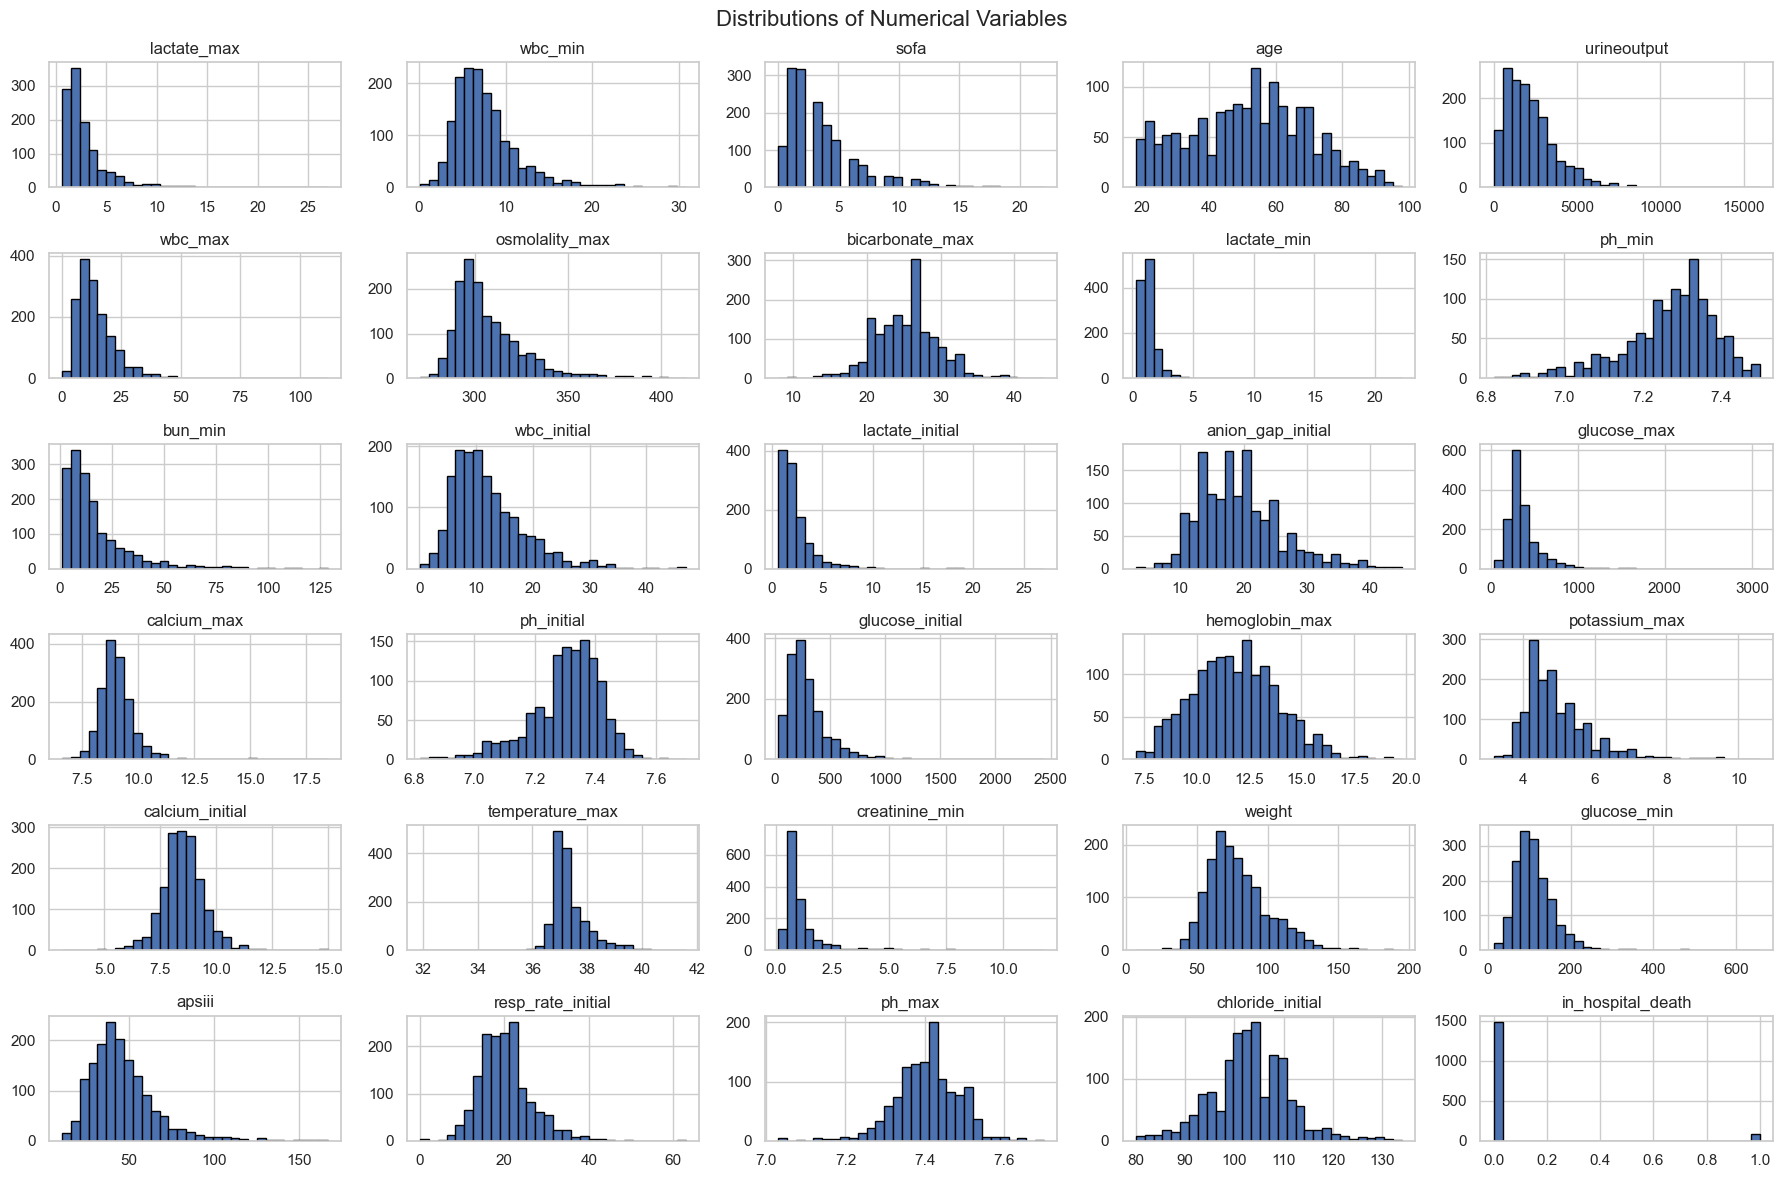

In [19]:
numeric_vars = real_shap_30.select_dtypes(include='number').columns.tolist()
plot_numerical_distributions(real_shap_30, numeric_vars)

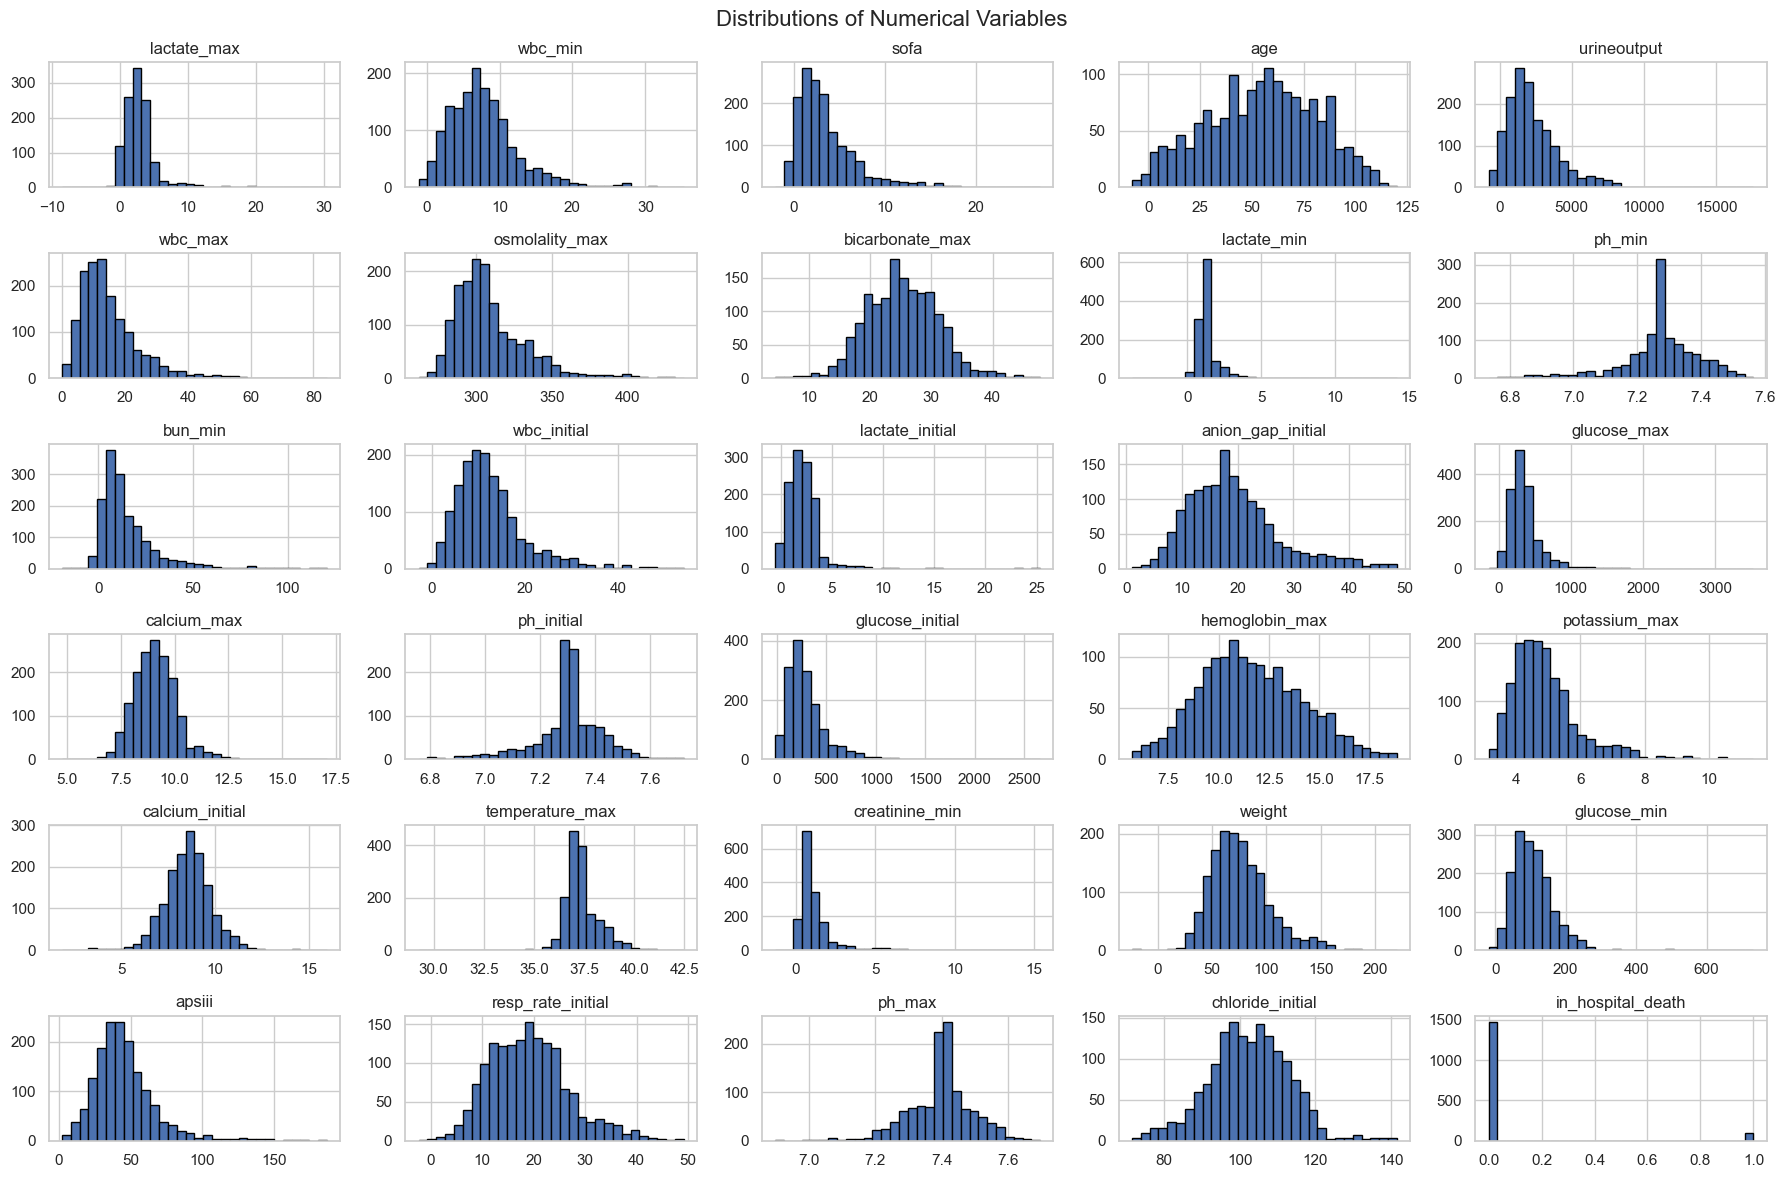

In [20]:
numeric_vars = syn_data_baseline.select_dtypes(include='number').columns.tolist()
plot_numerical_distributions(syn_data_baseline, numeric_vars)

In [21]:
def compare_correlation_maps(df_list, names, numeric_vars):

    fig, axes = plt.subplots(2, len(df_list), figsize=(7 * len(df_list), 18))

    # ---------- ROW 1: FULL CORRELATION HEATMAPS ----------
    for i, (df, name) in enumerate(zip(df_list, names)):
        corr = df[numeric_vars].corr()

        sns.heatmap(
            corr, 
            cmap='coolwarm', 
            annot=False, 
            fmt=".2f", 
            square=True, 
            ax=axes[0, i], 
            cbar=(i == len(df_list)-1)
        )
        axes[0, i].set_title(f"Correlation Heatmap\n{name}")

    # ---------- ROW 2: CORRELATION WITH OUTCOME ----------
    for i, (df, name) in enumerate(zip(df_list, names)):
        corr = df.corr(numeric_only=True)
        corr_with_y = corr[['in_hospital_death']]

        # 2) Reindex rows using the REAL ordering
        order = corr_with_y['in_hospital_death'].abs().sort_values(ascending=True).index
        corr_with_y = corr_with_y.reindex(order)

        sns.heatmap(
            corr_with_y,
            cmap='coolwarm',
            center=0,
            annot=True,
            fmt=".2f",
            ax=axes[1, i],
            cbar=(i == len(df_list)-1)
        )

        axes[1, i].set_title(f"Correlation with in_hospital_death\n{name}", fontsize=14)
        axes[1, i].set_yticks(range(len(corr_with_y.index)))
        axes[1, i].set_yticklabels(corr_with_y.index, fontsize=10)
        axes[1, i].set_xticklabels(["in_hospital_death"], fontsize=10)

    plt.tight_layout()
    plt.show()


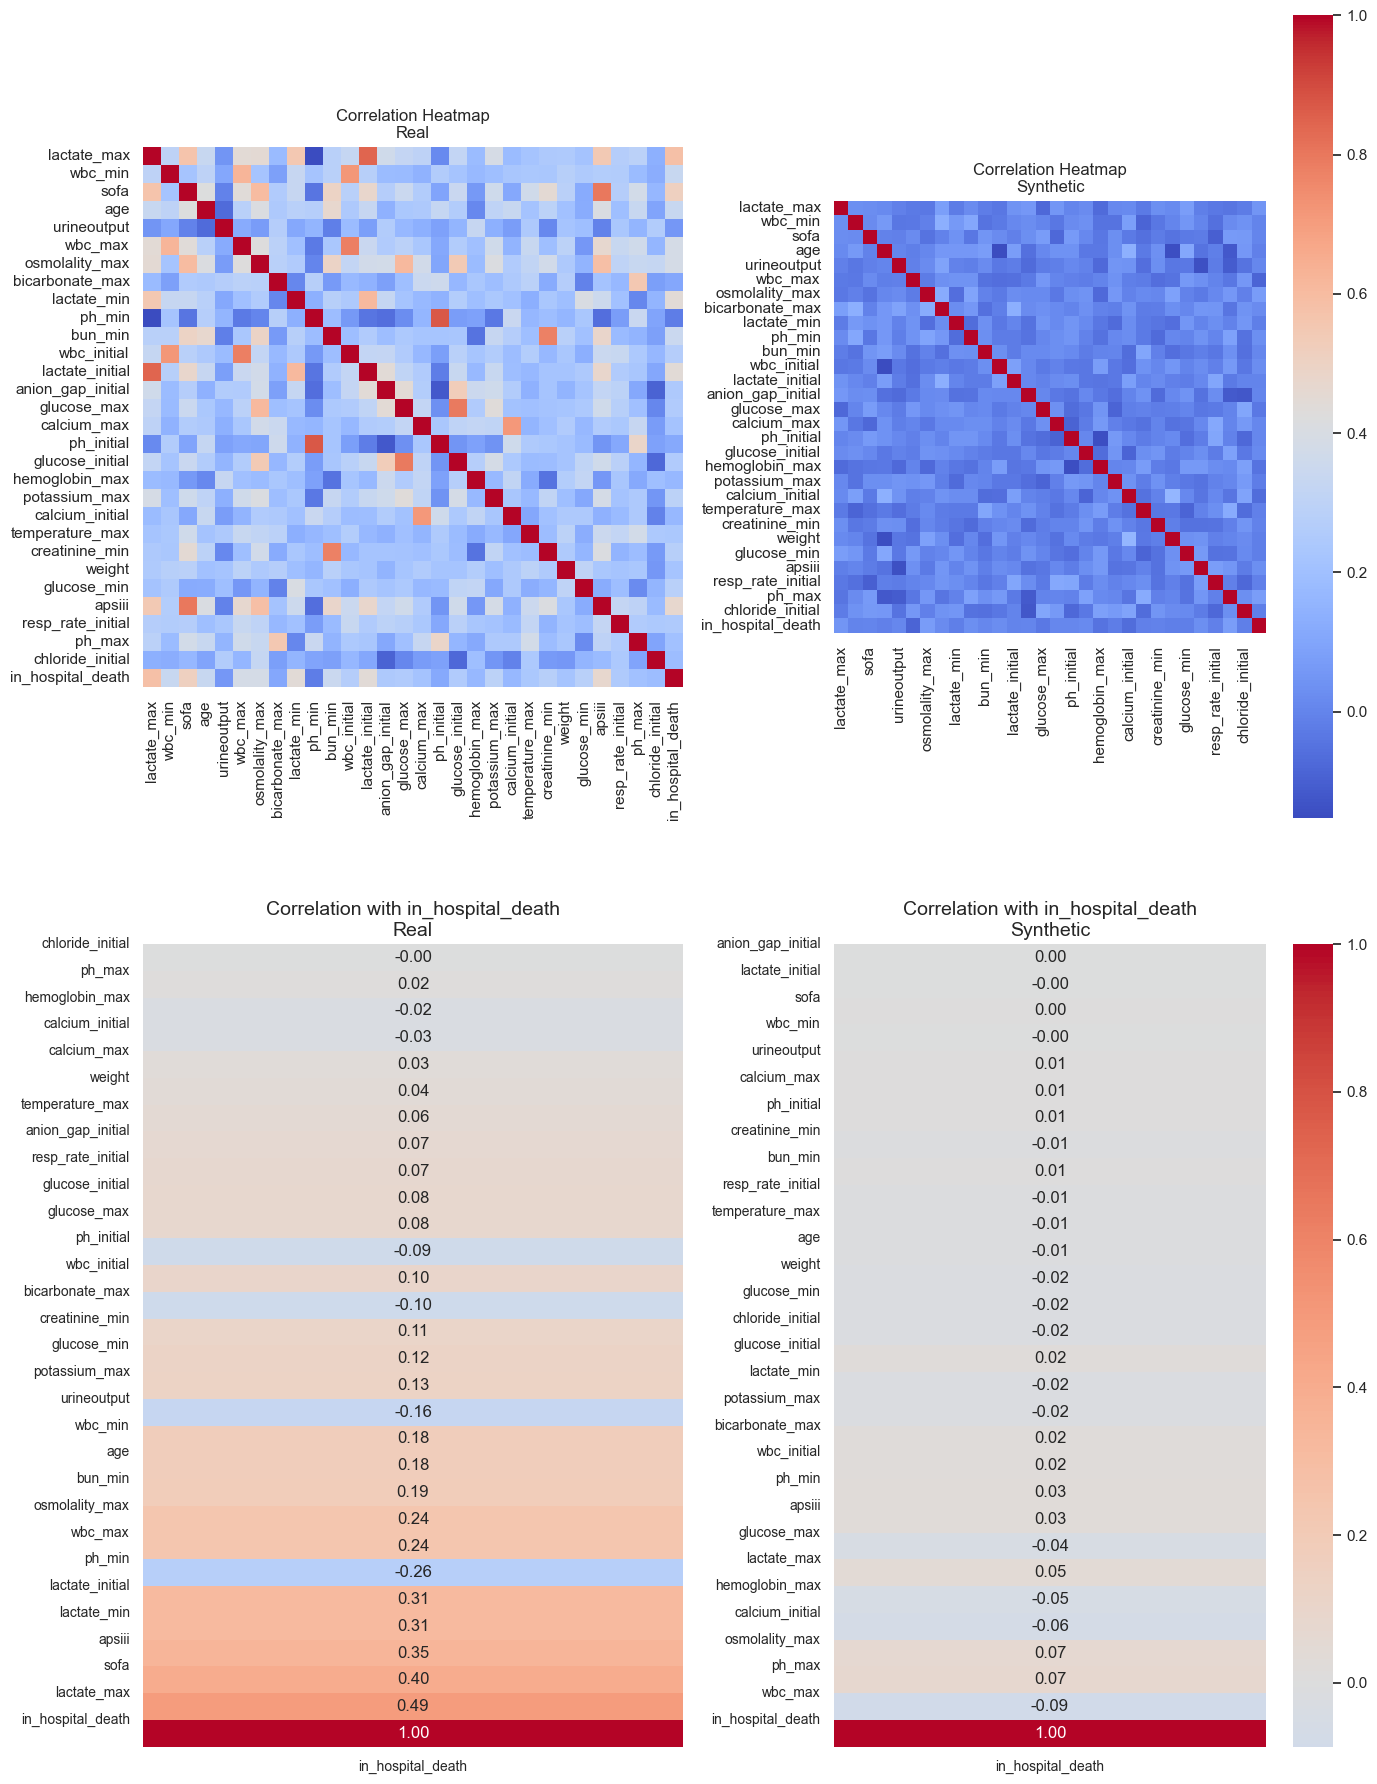

In [23]:
df_list = [real_shap_30, syn_data_baseline] #, syn_data_shap]
names = ["Real", "Synthetic"]#, "Synthetic SHAP"]

compare_correlation_maps(df_list, names, numeric_vars)


## Exploratory Data Analysis


In [24]:
def compare_histograms(df_list, names, column, bins=20):
    n = len(df_list)

    plt.figure(figsize=(6 * n, 5))  # Wider figure depending on number of DF

    for i, (df, name) in enumerate(zip(df_list, names)):
        plt.subplot(1, n, i+1)   # 1 row, n columns
        data = df[column].dropna().astype(float)

        sns.histplot(data, bins=bins, kde=False)
        plt.title(f"{name} — {column}")
        plt.xlabel(column)
        plt.ylabel("Count")

    plt.tight_layout()
    plt.show()
 


### Distribution of age

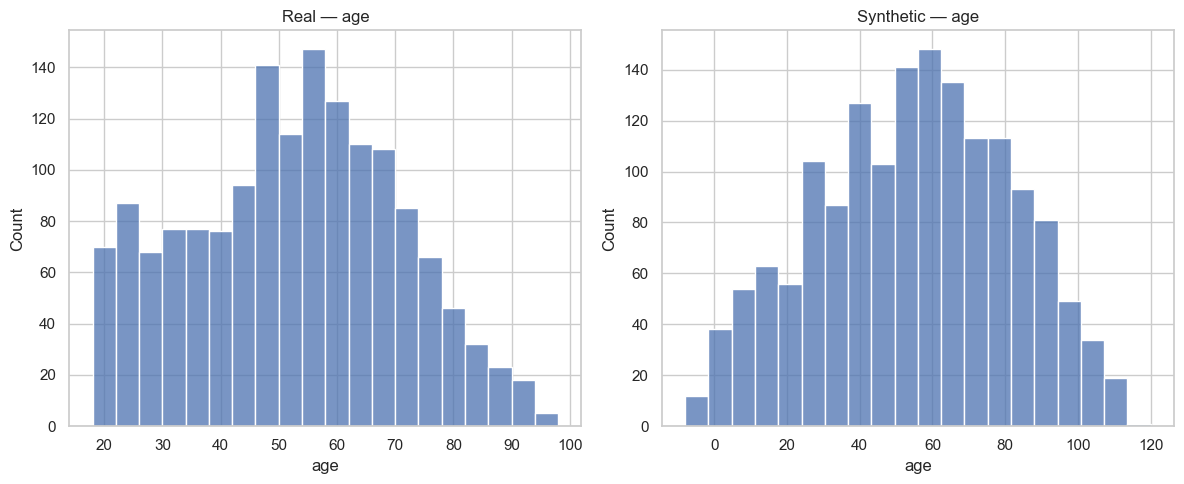

In [25]:
compare_histograms(df_list, names, column="age", bins=20)

### Distribution of the weight

Outlier the weight?

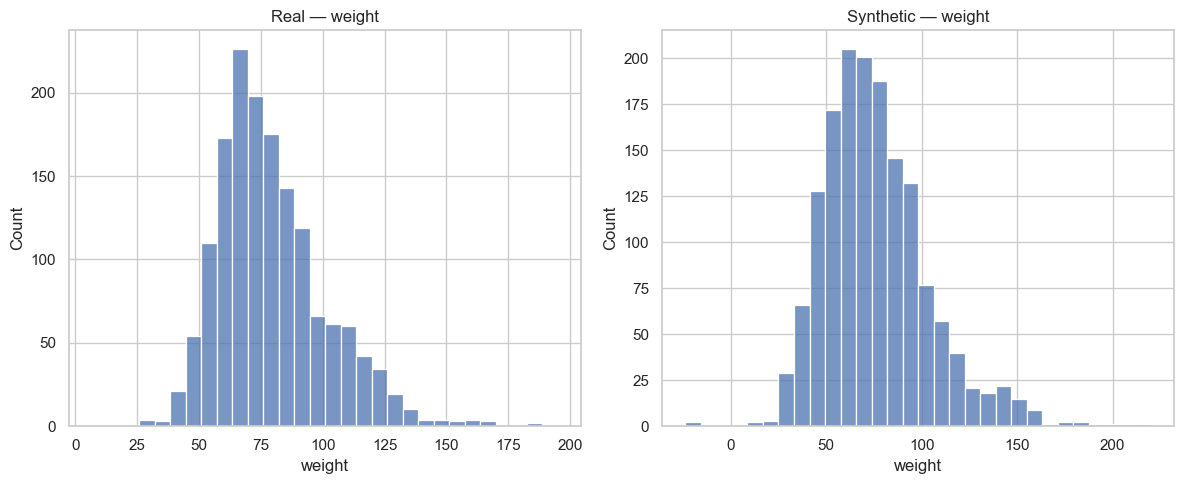

In [26]:
compare_histograms(df_list, names, column="weight", bins=30)

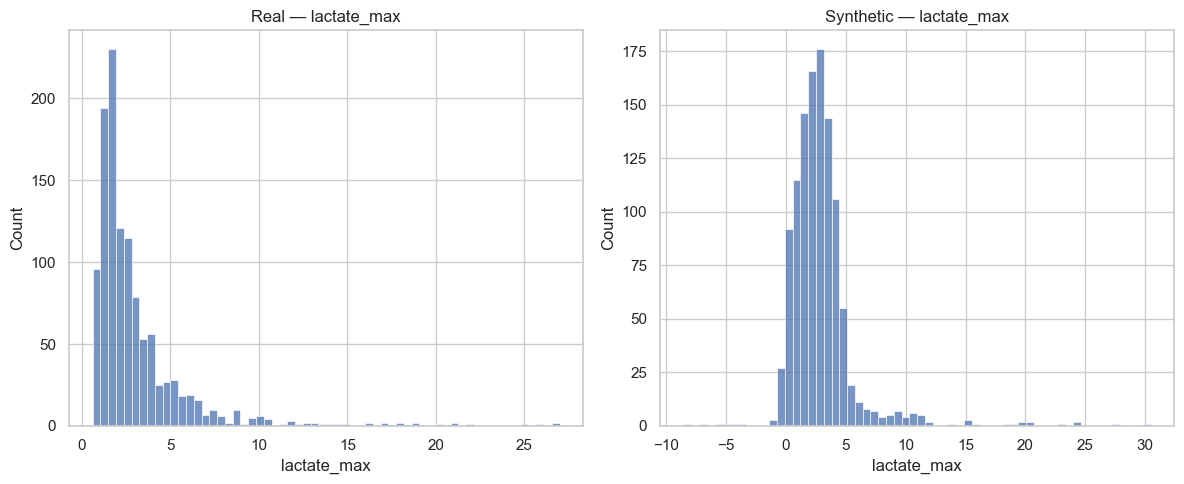

In [37]:
compare_histograms(df_list, names, column="lactate_max", bins=60)

## Categorical - Race

<Figure size 1200x1000 with 0 Axes>

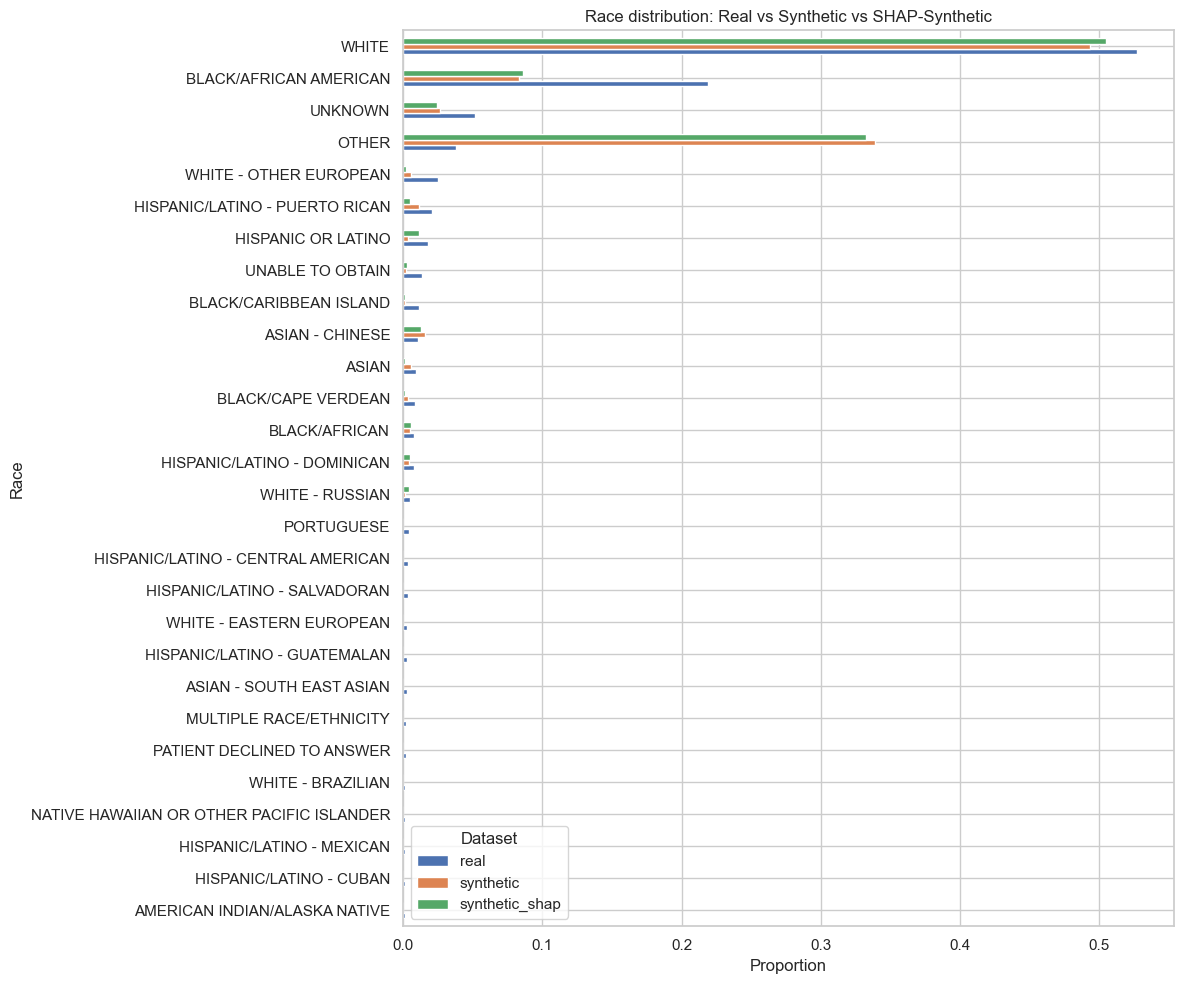

In [27]:
def get_cat_counts(df, colname, label):
    # vc = df[colname].value_counts(dropna=False) # If I want counts instead of proportions
    vc = df[colname].value_counts(normalize=True, dropna=False)
    return (
        vc.rename("count")
          .reset_index()
          .rename(columns={"index": colname})
          .assign(dataset=label)
    )

df_real  = get_cat_counts(real_shap_30, "race", "real")
df_syn   = get_cat_counts(syn_data_baseline, "race", "synthetic")
df_syn_s = get_cat_counts(syn_data_shap, "race", "synthetic_shap")

all_counts = pd.concat([df_real, df_syn, df_syn_s], ignore_index=True)

pivot = all_counts.pivot(index="race", columns="dataset", values="count").fillna(0)
pivot = pivot.sort_values("real", ascending=True)

plt.figure(figsize=(12, 10))
pivot.plot(kind="barh", figsize=(12, 10))

plt.xlabel("Proportion") # "Count" to "Proportion"
plt.ylabel("Race")
plt.title("Race distribution: Real vs Synthetic vs SHAP-Synthetic")
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()



In [29]:
def get_categorical_vars_value(df, categorical_vars):
    for col in categorical_vars:
        if col in df.columns:
            print(f"\n{col}:\n", df[col].value_counts(dropna=False))


In [30]:
categorical_vars = ['race']
get_categorical_vars_value(real_shap_30, categorical_vars)
get_categorical_vars_value(syn_data_baseline, categorical_vars)
get_categorical_vars_value(syn_data_shap, categorical_vars)



race:
 race
WHITE                                        829
BLACK/AFRICAN AMERICAN                       344
UNKNOWN                                       81
OTHER                                         59
WHITE - OTHER EUROPEAN                        39
HISPANIC/LATINO - PUERTO RICAN                32
HISPANIC OR LATINO                            28
UNABLE TO OBTAIN                              21
BLACK/CARIBBEAN ISLAND                        18
ASIAN - CHINESE                               17
ASIAN                                         14
BLACK/CAPE VERDEAN                            13
HISPANIC/LATINO - DOMINICAN                   12
BLACK/AFRICAN                                 12
WHITE - RUSSIAN                                8
PORTUGUESE                                     6
HISPANIC/LATINO - SALVADORAN                   5
HISPANIC/LATINO - CENTRAL AMERICAN             5
ASIAN - SOUTH EAST ASIAN                       4
WHITE - EASTERN EUROPEAN                       4
HISPANI

### Binary distribution

In [31]:
def compare_categorical_distributions(df_list, names, column):
    """
    Plot one figure with multi-dataset categorical distributions.
    Each category gets a grouped bar (one bar per dataset).
    """

    # Build tidy dataframe with counts
    frames = []
    for df, name in zip(df_list, names):
        vc = df[column].value_counts(dropna=False, normalize=False)
        temp = pd.DataFrame({
            column: vc.index.astype(str),
            "count": vc.values,
            "dataset": name
        })
        frames.append(temp)

    data = pd.concat(frames, ignore_index=True)

    # Create the plot
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=data,
        x=column,
        y="count",
        hue="dataset"
    )

    plt.title(f"{column} Distribution Comparison", fontsize=14)
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Deads
 In hospital death

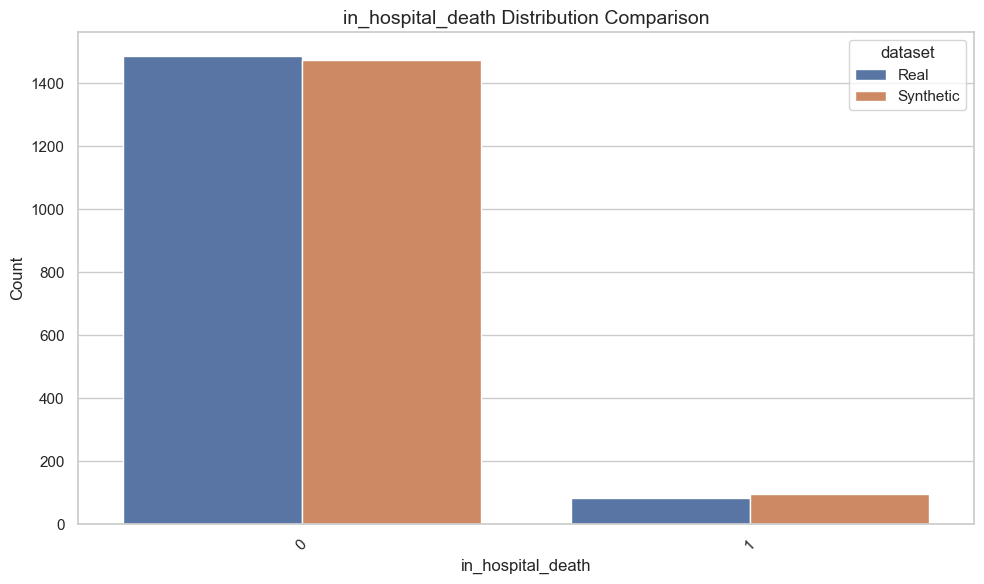

In [32]:

compare_categorical_distributions(df_list, names, column="in_hospital_death")

### Gender

### Insurance

### Emegency


### Laboratory test   TODO

In [ ]:
lab_features = [
    'ph_initial', 'calcium_initial', 'creatinine_initial',
    'hemoglobin_initial', 'wbc_initial', 'lactate_initial', 'osmolality_initial'
]

for feature in lab_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=real_shap_30, x='in_hospital_death', y=feature)
    plt.title(f'{feature} by Death Outcome')
    plt.show()




In [ ]:
comorbidities = [
    'aki', 'ckd', 'diabetes_with_cc',
    'diabetes_without_cc', 'cardiac_disease', 'hypertension', 'copd'
]

comorbidity_counts = real_shap_30.groupby('in_hospital_death')[comorbidities].sum().T
comorbidity_counts.columns = ['Survived', 'Died']
comorbidity_counts.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Comorbidities by Death Outcome')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Characteristic at baseline between survivors and non-survivors group

In [ ]:
!pip install tableone
!pip install --upgrade statsmodels

In [1]:
import sys
!{sys.executable} -m pip install scipy
!pip install pandas==2.1.4


[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 82.5 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.0.2
    Uninstalling pandas-2.0.2:
      Successfully uninstalled pandas-2.0.2

[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [94]:
import pandas as pd
import numpy as np
from scipy.stats import normaltest, kurtosistest
from tableone import TableOne

In [3]:
def get_nonnormal_columns(df, alpha=0.05):
    # Agostino and Anscombe tests
    # D’Agostino and Pearson Normality Test
    non_normal_cols = []
    for col in df.columns:
        data = df[col].dropna()
        if len(data) < 8:
            continue

        stat_nt, p_nt = normaltest(data)
        stat_kg, p_kg = kurtosistest(data)
        if p_nt < alpha or p_kg < alpha:
            non_normal_cols.append(col)
    return non_normal_cols

In [4]:
# Load your dataset
data = pd.read_csv('icu_dka_dataset_20250723.csv')

# Define labels and columns
column_labels = {
    'age': 'Age (year)',
    'gender': 'Male (%)',
    'race': 'White (%)',
    'heart_rate_initial': 'Heartrate (bpm)',
    'heart_rate_max': 'Heartrate_max (bpm)',
    'mbp_initial': 'MAP (mmHg)',
    'mbp_min': 'MAP_min (mmHg)',
    'resp_rate_initial': 'Respiratory_rate (insp/min)',
    'resp_rate_max': 'Respiratoryrate_max (insp/min)',
    'urineoutput': 'Urineoutput (ml)',
    'apsiii': 'APS III score',
    'sofa': 'SOFA score',
    'gcs': 'GCS score',
    'cns': 'CNS score',
    'renal': 'Renal score',
    'weight': 'Weight (kg)',
    'emergency': 'Admission, emergency (%)',
    'ventilation': 'Ventilation (%)',
    'nitroprusside': 'Nitrate pune (%)',
    'vasopressor': 'Vasopressor (%)',
    'albumin': 'Albumin (%)',
    'aki': 'AKI (%)',
    'ckd': 'CKD (%)',
    'cardiac_disease': 'Cardiac disease (%)',
    'hypertension': 'Hypertension (%)',
    'copd': 'COPD (%)',
    'lactate_max': 'Lactate_max (mmol/L)',
    'creatinine_initial': 'Scr (mg/dL)',
    'creatinine_max': 'Scr_max (mg/dL)',
    'ph_initial': 'PH',
    'ph_min': 'PH_min',
    'glucose_initial': 'Glucose (mg/dL)',
    'glucose_max': 'Glucose_max (mg/dL)',
    'sodium_initial': 'Sodium (mEq/L)',
    'sodium_max': 'Sodium_max (mEq/L)',
    'potassium_initial': 'Potassium (mEq/L)',
    'potassium_max': 'Potassium_max (mEq/L)',
    'calcium_initial': 'Calcium (mg/dL)',
    'chloride_initial': 'Chloride (mEq/L)',
    'wbc_initial': 'WBC (K/uL)',
    'wbc_max': 'WBC_max (K/uL)',
    'platelet_initial': 'PLT (K/uL)',
    'platelet_min': 'PLT_min (K/uL)',
    'bun_max': 'BUN_max (mg/dL)',
    'osmolality_initial': 'osmolarity',
    'osmolality_max': 'osmolarity_max',
    'osmolality_min': 'osmolarity_min'
}

columns = list(column_labels.keys())

categorical = [
    'gender', 'race', 'emergency', 'ventilation', 'nitroprusside', 'vasopressor',
    'albumin', 'aki', 'ckd', 'cardiac_disease', 'hypertension', 'copd'
]
continuous = [col for col in columns if col not in categorical]


labels = {var: {1: column_labels[var]} for var in categorical}
# print(labels)

# Custom labels
survivors_n = len(data[data['in_hospital_death'] == 0])
nonsurvivors_n = len(data[data['in_hospital_death'] == 1])
data['in_hospital_death_label'] = data['in_hospital_death'].map({
    1: f'Nonsurvivors (n={nonsurvivors_n})',
    0: f'Survivors (n={survivors_n})'
})

limit={
    'gender':1,
    'race':1
}

nonnormal = get_nonnormal_columns(data[continuous])
# Remove age to simulate the paper table
nonnormal.remove('age')

# Create TableOne
table = TableOne(
    data,
    columns=columns,
    categorical=categorical,
    labels=labels,
    groupby='in_hospital_death_label',
    pval=True,
    rename=column_labels,
    label_suffix=False,
    missing=False,
    limit=limit,
    decimals=2,
    nonnormal=nonnormal
)

# Print TableOne
print(table.tabulate(tablefmt="github"))


|                                |       | Overall                   | Nonsurvivors (n=83)     | Survivors (n=1488)        | P-Value   |
|--------------------------------|-------|---------------------------|-------------------------|---------------------------|-----------|
| n                              |       | 1571                      | 83                      | 1488                      |           |
| Age (year)                     |       | 51.94 (17.97)             | 65.59 (15.56)           | 51.18 (17.80)             | <0.001    |
| Male (%)                       | M     | 827 (52.64)               | 44 (53.01)              | 783 (52.62)               | 1.000     |
| White (%)                      | WHITE | 829 (52.77)               | 30 (36.14)              | 799 (53.70)               | <0.001    |
| Heartrate (bpm)                |       | 97.00 [85.00,109.00]      | 95.00 [81.50,108.50]    | 97.00 [85.00,109.00]      | 0.602     |
| Heartrate_max (bpm)            |       

In [62]:
table.to_csv('table.csv')

In [5]:
table.tabulate(tablefmt="latex")

'\\begin{tabular}{llllll}\n\\hline\n                                &       & Overall                   & Nonsurvivors (n=83)     & Survivors (n=1488)        & P-Value   \\\\\n\\hline\n n                              &       & 1571                      & 83                      & 1488                      &           \\\\\n Age (year)                     &       & 51.94 (17.97)             & 65.59 (15.56)           & 51.18 (17.80)             & \\ensuremath{<}0.001    \\\\\n Male (\\%)                       & M     & 827 (52.64)               & 44 (53.01)              & 783 (52.62)               & 1.000     \\\\\n White (\\%)                      & WHITE & 829 (52.77)               & 30 (36.14)              & 799 (53.70)               & \\ensuremath{<}0.001    \\\\\n Heartrate (bpm)                &       & 97.00 [85.00,109.00]      & 95.00 [81.50,108.50]    & 97.00 [85.00,109.00]      & 0.602     \\\\\n Heartrate\\_max (bpm)            &       & 106.00 [95.25,119.00]     & 111.00 [98.